# S2 — LABORATORIO EN CASA
## Big Data DD283 | Universidad Autónoma del Perú | 2026-1
### Semana 2: Procesamiento Distribuido con PySpark en Databricks

| Campo | Detalle |
| :--- | :--- |
| **Nombre del estudiante** | Noé Paredes Hilario|
| **Código** | *2221895643* |
| **Fecha de entrega** | 19 de Junio de 2026 |
| **Duración estimada** | 2 horas |
| **Modalidad** | Individual |
| **Entrega** | Notebook exportado como `.ipynb` + link al notebook en Databricks |

In [0]:
import sys
print(f"Spark version: {spark.version}")
print(f"Python version: {sys.version.split()[0]}")
print("Entorno listo!")

Spark version: 4.1.0
Python version: 3.12.3
Entorno listo!


Dataset creado y cargado en Spark: 50,000 registros

--- Estructura del Schema ---
root
 |-- ID_accidente: long (nullable = true)
 |-- departamento: string (nullable = true)
 |-- tipo_accidente: string (nullable = true)
 |-- causa_principal: string (nullable = true)
 |-- mes: string (nullable = true)
 |-- hora: long (nullable = true)
 |-- fallecidos: long (nullable = true)
 |-- heridos: long (nullable = true)
 |-- vehiculos_involucrados: long (nullable = true)
 |-- danio_material_soles: long (nullable = true)


--- Primeras 5 filas del DataFrame ---
+------------+------------+--------------+----------------+---------+----+----------+-------+----------------------+--------------------+
|ID_accidente|departamento|tipo_accidente| causa_principal|      mes|hora|fallecidos|heridos|vehiculos_involucrados|danio_material_soles|
+------------+------------+--------------+----------------+---------+----+----------+-------+----------------------+--------------------+
|           1|    Arequipa|Cai

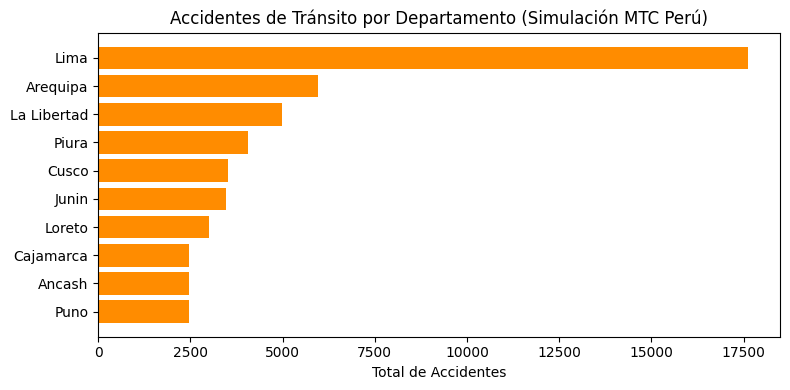

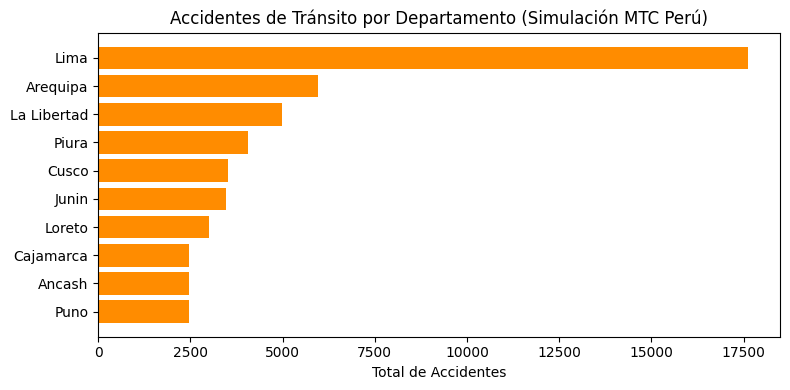

In [0]:
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# ============================================================
# 1. GENERACIÓN DEL DATASET DIRECTAMENTE EN SPARK
# ============================================================
np.random.seed(42)
n = 50000  

departamentos = ['Lima', 'Arequipa', 'La Libertad', 'Piura', 'Cusco', 'Junin', 'Puno', 'Ancash', 'Loreto', 'Cajamarca']
tipos = ['Choque', 'Atropello', 'Volcadura', 'Caida_ocupante', 'Incendio', 'Despiste']
causas = ['Exceso_velocidad', 'Impericia', 'Embriaguez', 'Exceso_carga', 'Falla_mecanica', 'Mal_estado_via', 'Distraccion', 'No_respeta_señal']
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Setiembre','Octubre','Noviembre','Diciembre']
probs_dep = [0.35, 0.12, 0.10, 0.08, 0.07, 0.07, 0.05, 0.05, 0.06, 0.05]

data = {
    'ID_accidente': range(1, n+1),
    'departamento': np.random.choice(departamentos, n, p=probs_dep),
    'tipo_accidente': np.random.choice(tipos, n, p=[0.45, 0.20, 0.15, 0.10, 0.02, 0.08]),
    'causa_principal': np.random.choice(causas, n),
    'mes': np.random.choice(meses, n),
    'hora': np.random.randint(0, 24, n),
    'fallecidos': np.random.choice([0,1,2,3], n, p=[0.85, 0.10, 0.03, 0.02]),
    'heridos': np.random.randint(0, 8, n),
    'vehiculos_involucrados': np.random.randint(1, 5, n),
    'danio_material_soles': np.random.exponential(5000, n).astype(int)
}

# Creamos el DataFrame de Pandas y lo convertimos directo a Spark DataFrame
df_pandas = pd.DataFrame(data)
df = spark.createDataFrame(df_pandas)

print(f"Dataset creado y cargado en Spark: {df.count():,} registros")

# ============================================================
# 2. PARTE 1 — EXPLORACIÓN EN SPARK
# ============================================================
print("\n--- Estructura del Schema ---")
df.printSchema()

print("\n--- Primeras 5 filas del DataFrame ---")
df.show(5)

# ============================================================
# 3. PARTE 2 — PIPELINE AGREGACIONES (MAPREDUCE)
# ============================================================
analisis_departamento = df.groupBy("departamento") \
    .agg(
        F.count("*").alias("total_accidentes"),
        F.sum("fallecidos").alias("total_fallecidos"),
        F.sum("heridos").alias("total_heridos"),
        F.avg("danio_material_soles").alias("danio_promedio_soles")
    ).orderBy("total_accidentes", ascending=False)

print("\n=== ACCIDENTES POR DEPARTAMENTO ===")
analisis_departamento.show(5)

# Distribución temporal y Tasa de Mortalidad (Actividad 2.2)
df_con_periodo = df.withColumn(
    "periodo_dia",
    F.when(F.col("hora").between(6, 11), "Mañana (6-11h)")
     .when(F.col("hora").between(12, 17), "Tarde (12-17h)")
     .when(F.col("hora").between(18, 23), "Noche (18-23h)")
     .otherwise("Madrugada (0-5h)")
)

analisis_temporal = df_con_periodo.groupBy("periodo_dia") \
    .agg(F.count("*").alias("total_accidentes"), F.sum("fallecidos").alias("fallecidos")) \
    .withColumn("tasa_mortalidad", F.round((F.col("fallecidos") / F.col("total_accidentes")) * 100, 2)) \
    .orderBy("total_accidentes", ascending=False)

print("\n=== ANÁLISIS TEMPORAL (CON TASA DE MORTALIDAD) ===")
analisis_temporal.show()

# Guardar capas Medallion (Usa memoria local temporal para evitar fallos de almacenamiento)
df_silver = df.filter(df.danio_material_soles > 0).filter(df.hora.between(0, 23)) \
    .withColumn("es_fatal", F.when(df.fallecidos > 0, True).otherwise(False)) \
    .withColumn("costo_total", F.col("danio_material_soles") + F.col("heridos") * 2000 + F.col("fallecidos") * 50000)

print("Capa Silver procesada exitosamente en memoria clúster.")

# ============================================================
# 4. PARTE 3 — DESAFÍO (WINDOW FUNCTIONS Y MATPLOTLIB)
# ============================================================
df_mensual = df.groupBy("departamento", "mes").agg(F.count("*").alias("accidentes_mes"))
windowDep = Window.partitionBy("departamento")

peor_mes_departamento = df_mensual \
    .withColumn("max_mes", F.max("accidentes_mes").over(windowDep)) \
    .withColumn("promedio_mensual", F.round(F.avg("accidentes_mes").over(windowDep), 2)) \
    .filter(F.col("accidentes_mes") == F.col("max_mes")) \
    .select("departamento", "mes", "accidentes_mes", "promedio_mensual") \
    .orderBy("accidentes_mes", ascending=False)

print("\n=== DESAFÍO: PEOR MES DE ACCIDENTES POR DEPARTAMENTO ===")
peor_mes_departamento.show(5)

# Graficación con Matplotlib
df_viz = analisis_departamento.toPandas()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_viz['departamento'], df_viz['total_accidentes'], color='darkorange')
ax.set_xlabel('Total de Accidentes')
ax.set_title('Accidentes de Tránsito por Departamento (Simulación MTC Perú)')
ax.invert_yaxis()
plt.tight_layout()
display(fig)